# 05 — AMCShield Final Results

This notebook presents the final experimental results for **AMCShield: Attack-Agnostic Robustness Generalization in Automatic Modulation Classification**.

It uses the **already generated result CSV/JSON artifacts and `master_results.csv`**. It does **not** retrain models and does **not** execute any adversarial attack.

### Evaluation scope
- Dataset: RadioML2018.01A
- Modulation classes: 24
- SNR range: −20 dB to +30 dB, 2 dB increments
- Robust training attack: PGD
- FGSM / PGD / MIM epsilon: 0.02
- PGD / MIM steps: 10
- Black-box surrogate query budget: 5,000
- Results are evaluated across 26 SNR points

**Important:** this notebook is an analysis/reporting layer over existing artifacts. It does not change the experimental results.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS = ROOT / "results"
PLOTS = RESULTS / "plots"

print("Project root:", ROOT)
print("Results directory:", RESULTS)
print("Results directory exists:", RESULTS.exists())

Project root: d:\MediCaps University\7 SEM\Project 1\AMCShield
Results directory: d:\MediCaps University\7 SEM\Project 1\AMCShield\results
Results directory exists: True


## 1. Load the final result artifacts

The notebook first loads `master_results.csv` and the individual baseline/robust evaluation files. The individual files are retained because the repository contains both robust-only master fields and baseline comparison files, depending on the version of the master-generation script.

In [2]:
master_path = RESULTS / "master_results.csv"
master = pd.read_csv(master_path)

files = {
    "baseline_clean": "baseline_clean_results.csv",
    "baseline_fgsm": "baseline_fgsm_results.csv",
    "baseline_pgd": "baseline_pgd_results.csv",
    "baseline_mim": "baseline_mim_results.csv",
    "baseline_cw": "baseline_cw_results.csv",
    "baseline_blackbox": "baseline_blackbox_results.csv",
    "robust_clean": "clean_results.csv",
    "robust_fgsm": "fgsm_results.csv",
    "robust_pgd": "pgd_results.csv",
    "robust_mim": "mim_results.csv",
    "robust_cw": "cw_results.csv",
    "robust_blackbox": "blackbox_results.csv",
    "generalization_gap": "generalization_gap.csv",
}

data = {}
for key, filename in files.items():
    path = RESULTS / filename
    data[key] = pd.read_csv(path)

print(f"master_results.csv: {len(master)} rows × {len(master.columns)} columns")
print("Master columns:")
print(master.columns.tolist())

print("\nIndividual result validation:")
for key, df in data.items():
    if "snr" in df.columns:
        print(f"{key:22s}: {len(df):2d} rows, {df['snr'].nunique():2d} SNR values")

master_results.csv: 26 rows × 62 columns
Master columns:
['snr', 'clean_accuracy', 'fgsm_accuracy', 'fgsm_asr', 'pgd_accuracy', 'pgd_asr', 'mim_accuracy', 'mim_asr', 'cw_accuracy', 'cw_asr', 'cw_mean_linf', 'cw_max_linf', 'cw_mean_l2', 'cw_max_l2', 'blackbox_accuracy', 'blackbox_asr', 'blackbox_mean_linf', 'blackbox_max_linf', 'blackbox_mean_l2', 'blackbox_max_l2', 'baseline_clean_accuracy', 'baseline_fgsm_accuracy', 'baseline_fgsm_asr', 'baseline_pgd_accuracy', 'baseline_pgd_asr', 'baseline_mim_accuracy', 'baseline_mim_asr', 'baseline_cw_accuracy', 'baseline_cw_asr', 'baseline_cw_mean_linf', 'baseline_cw_max_linf', 'baseline_cw_mean_l2', 'baseline_cw_max_l2', 'baseline_blackbox_accuracy', 'baseline_blackbox_asr', 'blackbox_gap', 'cw_gap', 'fgsm_gap', 'mim_gap', 'pgd_gap', 'clean_accuracy_pct', 'fgsm_accuracy_pct', 'fgsm_asr_pct', 'pgd_accuracy_pct', 'pgd_asr_pct', 'mim_accuracy_pct', 'mim_asr_pct', 'cw_accuracy_pct', 'cw_asr_pct', 'blackbox_accuracy_pct', 'blackbox_asr_pct', 'baseline

In [3]:
expected_snrs = list(range(-20, 31, 2))

for key, df in data.items():
    if "snr" in df.columns:
        actual = sorted(df["snr"].astype(int).unique().tolist())
        assert actual == expected_snrs, f"Unexpected SNR values in {key}: {actual}"

assert len(master) == 26
assert sorted(master["snr"].astype(int).unique().tolist()) == expected_snrs

print("Validation passed: 26 SNR points from -20 dB to +30 dB are present.")

Validation passed: 26 SNR points from -20 dB to +30 dB are present.


## 2. Normalize result units for reporting

The generated artifacts use mixed internal representations: some robust accuracy/ASR fields are stored as fractions while baseline result files store percentages. The cells below convert everything used in the final comparison to **0–100%** without changing the source files.

In [4]:
def as_percent(series):
    s = pd.Series(series, dtype=float)
    # Robust attack files store ASR as fractions; baseline files store percentages.
    # This helper is used only where the source convention is known.
    return s * 100

baseline_clean_pct = data["baseline_clean"]["clean_accuracy"].astype(float)
robust_clean_pct = data["robust_clean"]["accuracy"].astype(float) * 100

baseline_attacks = {
    "FGSM": data["baseline_fgsm"],
    "PGD": data["baseline_pgd"],
    "MIM": data["baseline_mim"],
    "C&W": data["baseline_cw"],
    "Black-box": data["baseline_blackbox"],
}

robust_attacks = {
    "FGSM": data["robust_fgsm"],
    "PGD": data["robust_pgd"],
    "MIM": data["robust_mim"],
    "C&W": data["robust_cw"],
    "Black-box": data["robust_blackbox"],
}

robust_fraction_attacks = {"FGSM", "PGD", "MIM", "C&W"}

print("Reporting units normalized to percentage points.")

Reporting units normalized to percentage points.


## 3. Clean-performance summary

In [5]:
clean_summary = pd.DataFrame({
    "Model": ["Baseline", "Robust"],
    "Mean Clean Accuracy (%)": [
        baseline_clean_pct.mean(),
        robust_clean_pct.mean(),
    ],
    "Minimum Accuracy (%)": [
        baseline_clean_pct.min(),
        robust_clean_pct.min(),
    ],
    "Maximum Accuracy (%)": [
        baseline_clean_pct.max(),
        robust_clean_pct.max(),
    ],
})

display(clean_summary.round(2))

,Model,Mean Clean Accuracy (%),Minimum Accuracy (%),Maximum Accuracy (%)
0,Baseline,78.97,7.03,100.00
1,Robust,55.18,4.16,86.41


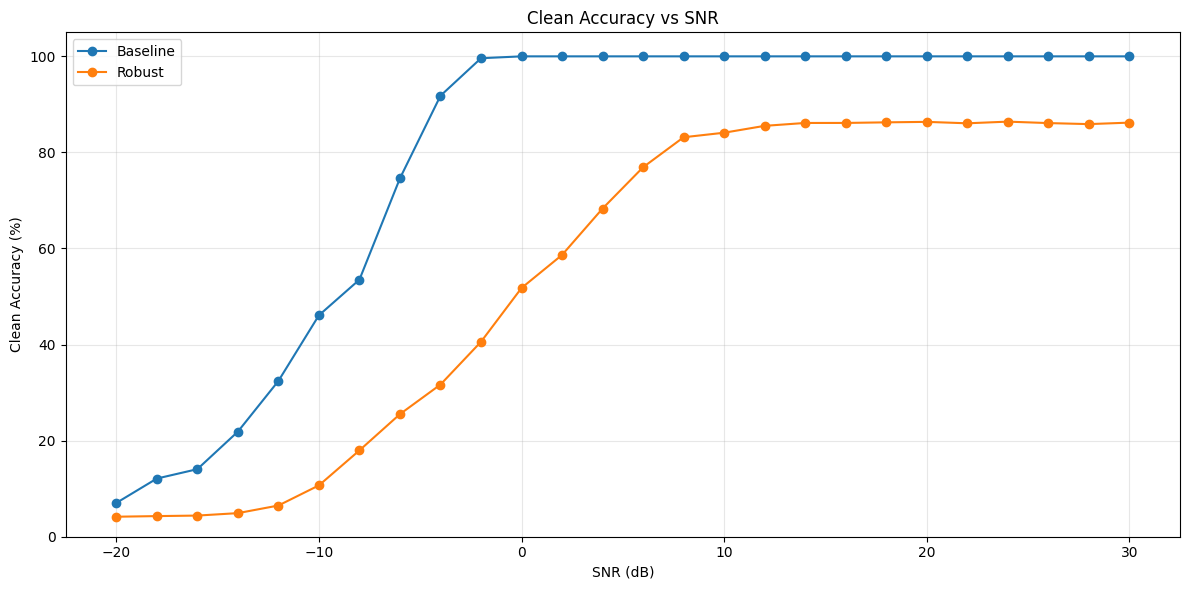

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(data["baseline_clean"]["snr"], baseline_clean_pct, marker="o", label="Baseline")
plt.plot(data["robust_clean"]["snr"], robust_clean_pct, marker="o", label="Robust")
plt.xlabel("SNR (dB)")
plt.ylabel("Clean Accuracy (%)")
plt.title("Clean Accuracy vs SNR")
plt.ylim(0, 105)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Attack-wise summary

Attack Success Rate (ASR) is summarized over all 26 SNR values. The table reports the baseline and robust means and their difference in percentage points.

In [7]:
summary_rows = []

for attack in ["FGSM", "PGD", "MIM", "C&W", "Black-box"]:
    b = baseline_attacks[attack]["attack_success_rate"].astype(float)
    r = robust_attacks[attack]["attack_success_rate"].astype(float)

    if attack in robust_fraction_attacks:
        r = r * 100

    summary_rows.append({
        "Attack": attack,
        "Baseline Mean ASR (%)": b.mean(),
        "Robust Mean ASR (%)": r.mean(),
        "Baseline − Robust Gap (pp)": b.mean() - r.mean(),
    })

attack_summary = pd.DataFrame(summary_rows)
display(attack_summary.round(2))

,Attack,Baseline Mean ASR (%),Robust Mean ASR (%),Baseline − Robust Gap (pp)
0,FGSM,25.81,21.69,4.11
1,PGD,22.68,19.25,3.43
2,MIM,22.40,19.35,3.05
3,C&W,85.14,94.47,-9.33
4,Black-box,6.11,7.69,-1.58


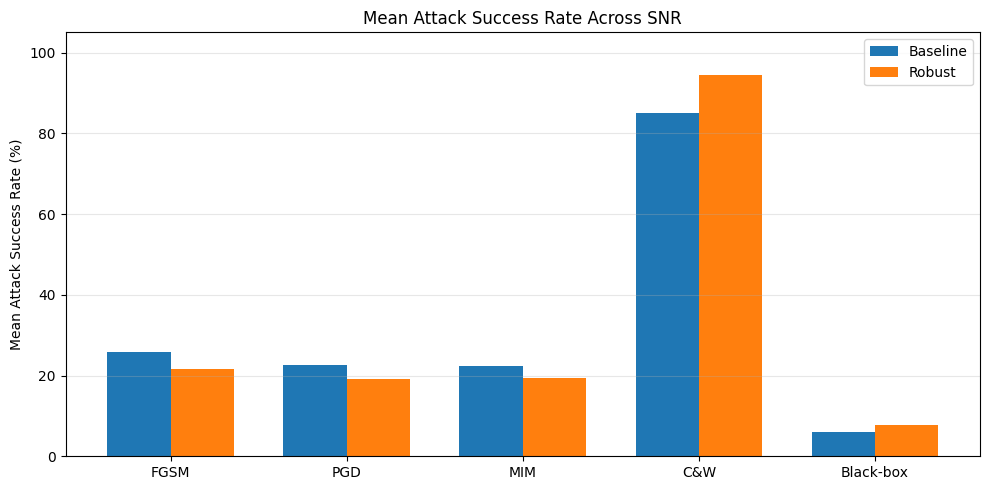

In [8]:
plt.figure(figsize=(10, 5))
x = np.arange(len(attack_summary))
width = 0.36

plt.bar(x - width / 2, attack_summary["Baseline Mean ASR (%)"], width, label="Baseline")
plt.bar(x + width / 2, attack_summary["Robust Mean ASR (%)"], width, label="Robust")
plt.xticks(x, attack_summary["Attack"])
plt.ylabel("Mean Attack Success Rate (%)")
plt.title("Mean Attack Success Rate Across SNR")
plt.ylim(0, 105)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 5. SNR-stratified attack curves

These plots show how the attack success rate changes with SNR. The comparison is made from the stored evaluation CSVs; no attack is generated here.

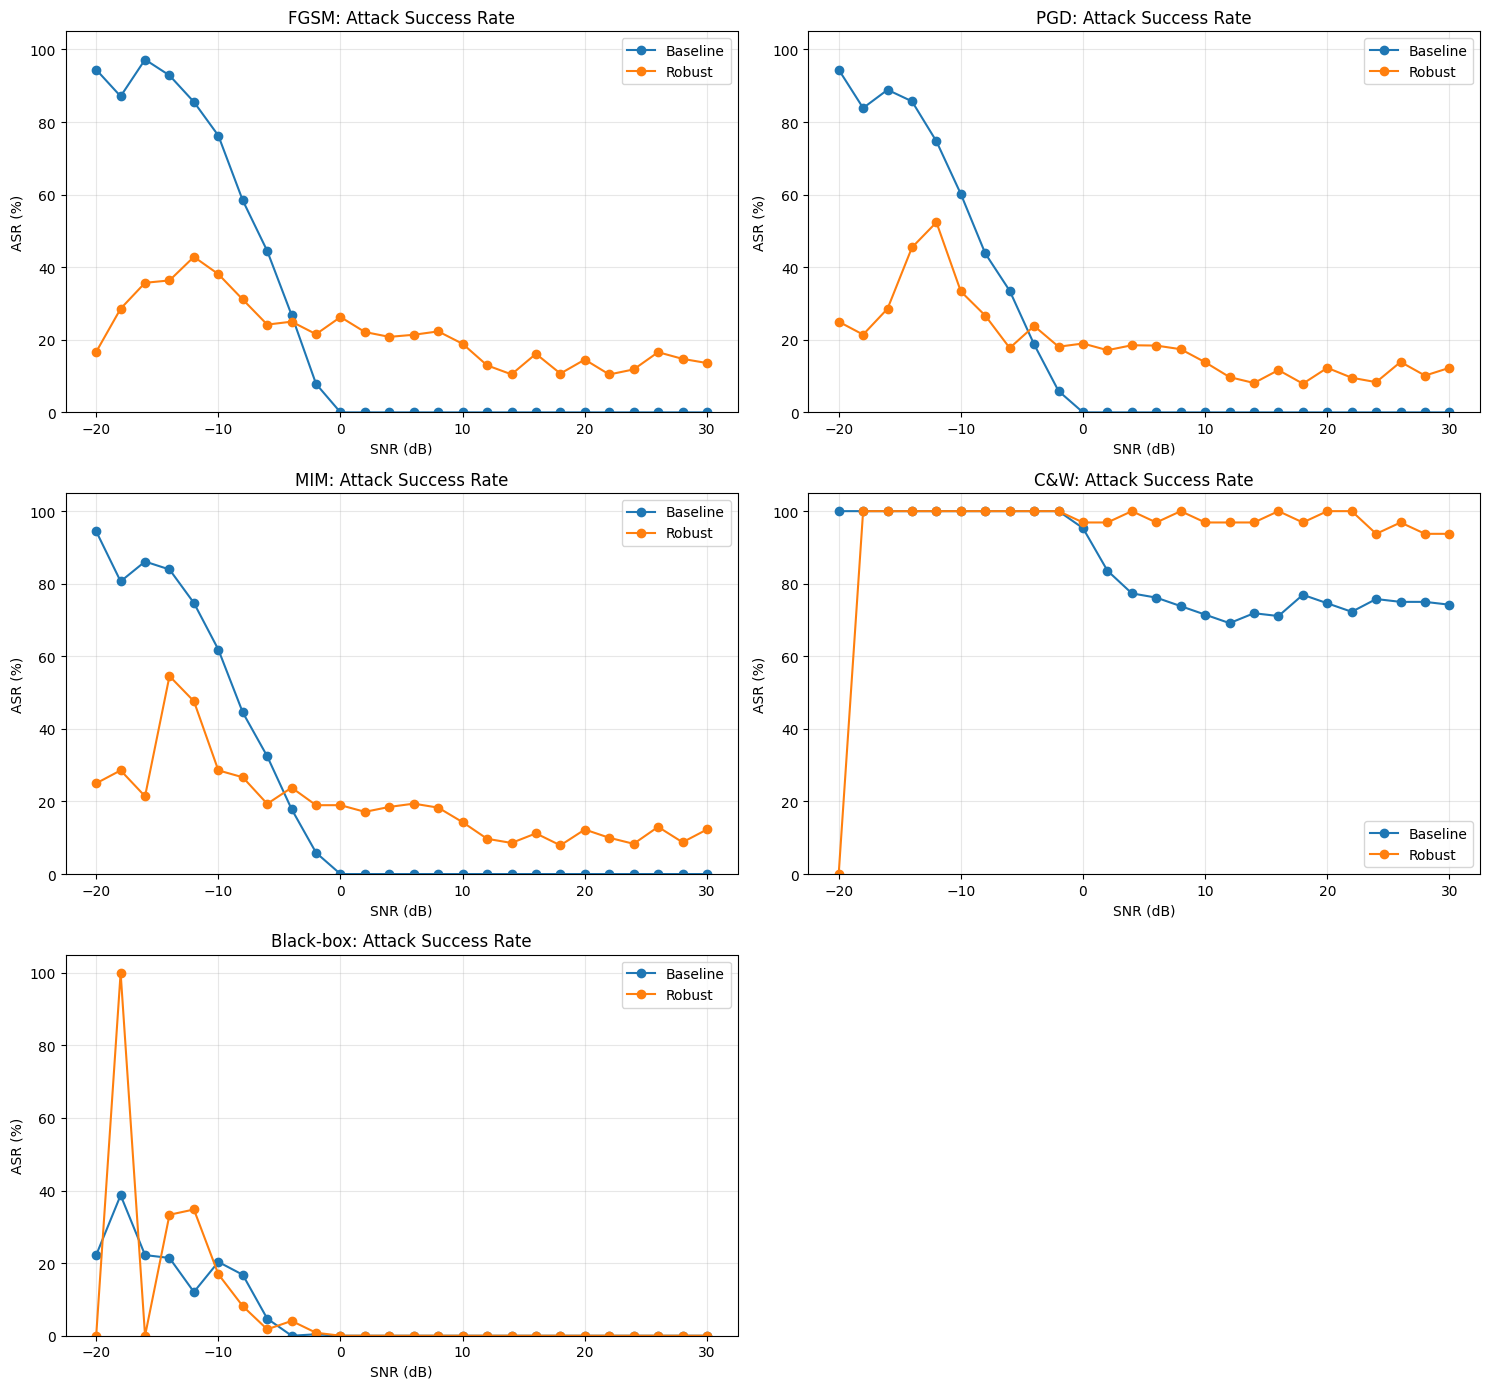

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(15, 14))
axes = axes.flatten()

for ax, attack in zip(axes, ["FGSM", "PGD", "MIM", "C&W", "Black-box"]):
    bdf = baseline_attacks[attack]
    rdf = robust_attacks[attack]

    b_asr = bdf["attack_success_rate"].astype(float)
    r_asr = rdf["attack_success_rate"].astype(float)
    if attack in robust_fraction_attacks:
        r_asr = r_asr * 100

    ax.plot(bdf["snr"], b_asr, marker="o", label="Baseline")
    ax.plot(rdf["snr"], r_asr, marker="o", label="Robust")
    ax.set_title(f"{attack}: Attack Success Rate")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("ASR (%)")
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].axis("off")
plt.tight_layout()
plt.show()

## 6. Generalization-gap analysis

The stored `generalization_gap.csv` defines the gap as:

**Generalization gap = Baseline ASR − Robust ASR**

Positive values indicate that the stored robust-model ASR is lower than the baseline ASR for that attack/SNR cell. Negative values indicate the opposite for that cell.

In [10]:
gap = data["generalization_gap"].copy()

required_gap_cols = {"attack", "snr", "baseline_asr", "robust_asr", "gap"}
missing = required_gap_cols - set(gap.columns)
assert not missing, f"Missing columns in generalization_gap.csv: {missing}"

display(gap.head(10).round(2))

gap_summary = (
    gap.groupby("attack")["gap"]
    .agg(["mean", "min", "max"])
    .rename(columns={"mean": "Mean Gap (pp)", "min": "Minimum Gap (pp)", "max": "Maximum Gap (pp)"})
    .reset_index()
)

display(gap_summary.round(2))

,attack,snr,baseline_asr,robust_asr,gap
0,FGSM,-20,94.44,0.17,94.28
1,FGSM,-18,87.10,0.29,86.81
2,FGSM,-16,97.22,0.36,96.87
3,FGSM,-14,92.86,0.36,92.49
4,FGSM,-12,85.54,0.43,85.11
5,FGSM,-10,76.27,0.38,75.89
6,FGSM,-8,58.39,0.31,58.08
7,FGSM,-6,44.50,0.24,44.26
8,FGSM,-4,26.81,0.25,26.56
9,FGSM,-2,7.84,0.22,7.63


,attack,Mean Gap (pp),Minimum Gap (pp),Maximum Gap (pp)
0,Black-box,-1.58,-61.29,22.22
1,C&W,84.20,68.17,100.00
2,FGSM,25.59,-0.26,96.87
3,MIM,22.21,-0.19,94.19
4,PGD,22.49,-0.19,94.19


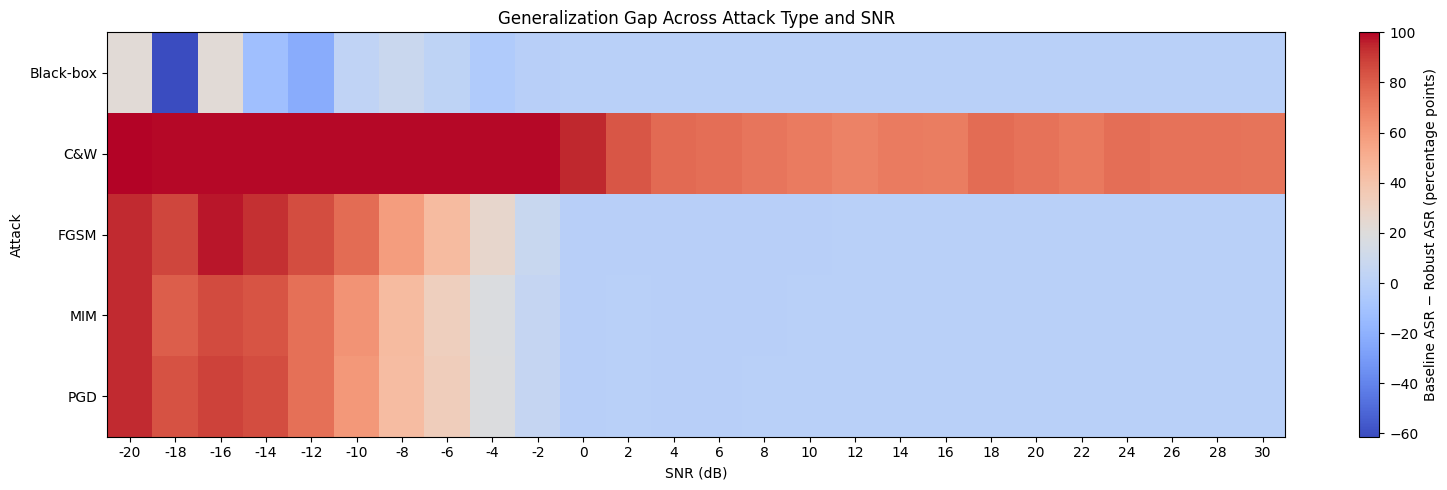

In [11]:
gap_pivot = gap.pivot(index="attack", columns="snr", values="gap")

plt.figure(figsize=(16, 5))
plt.imshow(gap_pivot.values, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Baseline ASR − Robust ASR (percentage points)")
plt.xticks(range(len(gap_pivot.columns)), gap_pivot.columns)
plt.yticks(range(len(gap_pivot.index)), gap_pivot.index)
plt.xlabel("SNR (dB)")
plt.ylabel("Attack")
plt.title("Generalization Gap Across Attack Type and SNR")
plt.tight_layout()
plt.show()

## 7. C&W distortion analysis

C&W is reported separately because its implementation does not use the same ε = 0.02 L∞ projection used by FGSM, PGD and MIM. Its L∞ and L2 distortion statistics therefore should not be interpreted as ε-bounded values.

In [12]:
cw_distortion_summary = pd.DataFrame({
    "Metric": [
        "Robust mean of mean L∞",
        "Robust maximum L∞",
        "Robust mean of mean L2",
        "Robust maximum L2",
    ],
    "Value": [
        robust_attacks["C&W"]["mean_linf"].mean(),
        robust_attacks["C&W"]["max_linf"].max(),
        robust_attacks["C&W"]["mean_l2"].mean(),
        robust_attacks["C&W"]["max_l2"].max(),
    ]
})

display(cw_distortion_summary.round(4))

,Metric,Value
0,Robust mean of mean L∞,2.1571
1,Robust maximum L∞,17.9776
2,Robust mean of mean L2,30.4613
3,Robust maximum L2,565.3749


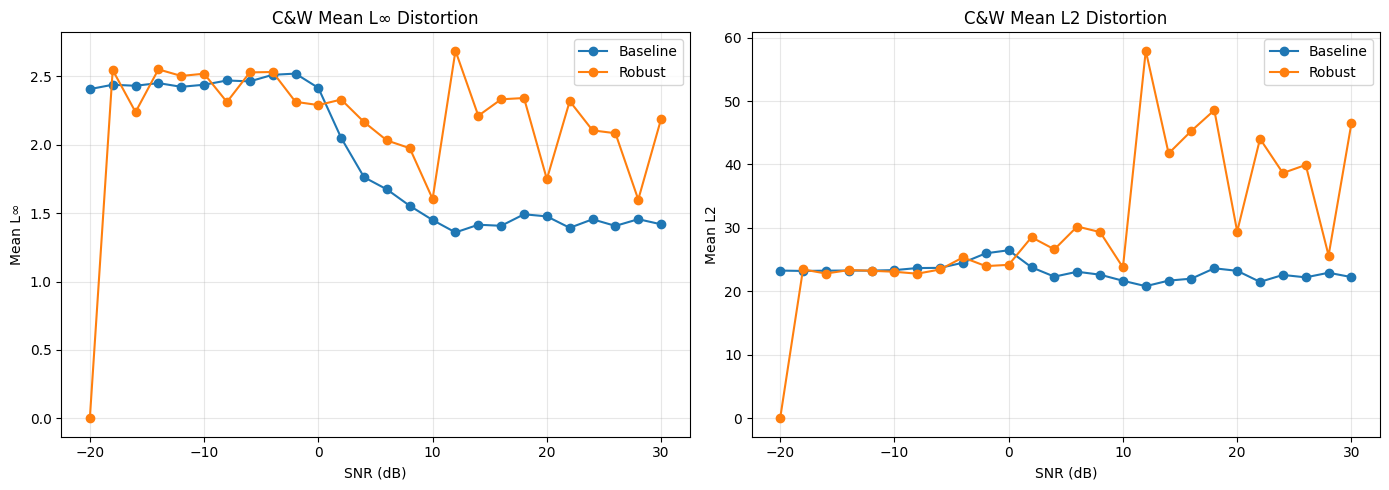

In [13]:
baseline_cw = data["baseline_cw"]
robust_cw = data["robust_cw"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(baseline_cw["snr"], baseline_cw["mean_linf"], marker="o", label="Baseline")
axes[0].plot(robust_cw["snr"], robust_cw["mean_linf"], marker="o", label="Robust")
axes[0].set_title("C&W Mean L∞ Distortion")
axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("Mean L∞")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(baseline_cw["snr"], baseline_cw["mean_l2"], marker="o", label="Baseline")
axes[1].plot(robust_cw["snr"], robust_cw["mean_l2"], marker="o", label="Robust")
axes[1].set_title("C&W Mean L2 Distortion")
axes[1].set_xlabel("SNR (dB)")
axes[1].set_ylabel("Mean L2")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Final results table

This compact table is intended for the report/PPT. It summarizes the mean values over the evaluated SNR points.

In [14]:
final_table = attack_summary.copy()
final_table["Baseline Mean ASR (%)"] = final_table["Baseline Mean ASR (%)"].round(2)
final_table["Robust Mean ASR (%)"] = final_table["Robust Mean ASR (%)"].round(2)
final_table["Baseline − Robust Gap (pp)"] = final_table["Baseline − Robust Gap (pp)"].round(2)

display(final_table)

print("\nClean accuracy summary:")
display(clean_summary.round(2))

,Attack,Baseline Mean ASR (%),Robust Mean ASR (%),Baseline − Robust Gap (pp)
0,FGSM,25.81,21.69,4.11
1,PGD,22.68,19.25,3.43
2,MIM,22.40,19.35,3.05
3,C&W,85.14,94.47,-9.33
4,Black-box,6.11,7.69,-1.58



Clean accuracy summary:


,Model,Mean Clean Accuracy (%),Minimum Accuracy (%),Maximum Accuracy (%)
0,Baseline,78.97,7.03,100.00
1,Robust,55.18,4.16,86.41


## 9. Key observations

The following observations are generated directly from the stored evaluation artifacts rather than from additional experiments.

1. **Clean accuracy is strongly SNR-dependent.** Both models show substantially lower classification accuracy at the lowest SNR values and substantially higher accuracy as SNR increases.

2. **The robust model was trained specifically with PGD.** The evaluation therefore includes PGD as the training-time attack and FGSM, MIM, C&W and black-box transfer as additional attack conditions.

3. **The attack response varies with SNR and attack type.** The SNR-stratified curves and heatmap show that robustness is not represented by a single constant value across the operating range.

4. **C&W behaves differently from the ε-bounded attacks.** Its attack-success and distortion results must be interpreted together because the current C&W implementation does not apply the same ε = 0.02 L∞ projection.

5. **Black-box transfer is a distinct threat model.** The surrogate is trained from target-model queries and the attack is transferred to the target; this is different from white-box gradient access.

6. **The generalization-gap heatmap is the central comparative artifact.** It exposes how the difference between baseline and robust ASR changes jointly with attack type and SNR.

The exact numerical summaries printed above should be used in the final report rather than manually copied from a separate source.

## 10. Limitations

- **Synthetic dataset:** RadioML2018.01A is synthetic; performance on real captured RF signals is not established by this experiment.
- **SNR scope:** conclusions are specific to the evaluated −20 dB to +30 dB range and the available dataset distribution.
- **C&W evaluation size:** the existing robust C&W result was evaluated on a smaller per-SNR subset than the other attack evaluations. It should not be described as a 300-sample-per-SNR result.
- **C&W constraint:** C&W is not constrained by the same ε = 0.02 L∞ projection used by FGSM, PGD and MIM.
- **Black-box surrogate:** transfer performance depends on the selected surrogate architecture and its 5,000-query training budget; it is not a universal worst-case black-box bound.
- **Sampled attack evaluations:** baseline and black-box attack evaluations use 256 samples per SNR rather than the complete test set.
- **Clean accuracy vs attack subsets:** sampled evaluation accuracy should not be presented as identical to the full-test clean accuracy.
- **No real-world channel modeling:** over-the-air, Rayleigh/Rician channel-aware attacks and SDR-based evaluation are outside the current scope.
- **No deployment claim:** this project evaluates robustness experimentally; it does not establish real-time or production deployment performance.

## 11. Conclusion

AMCShield provides an SNR-stratified evaluation of a baseline AMC classifier and a PGD-adversarially trained robust classifier across multiple attack families. The final analysis combines clean accuracy, attack success rate, C&W distortion statistics, black-box transfer evaluation, and the baseline-versus-robust generalization gap.

The results show that adversarial robustness is **attack- and SNR-dependent**, so a single robustness measurement is insufficient to describe the model's behavior across the full evaluation space. The generalization-gap heatmap provides the main evidence for examining how robustness against the training-time PGD attack relates to behavior under other attack mechanisms and SNR conditions.

These findings should be interpreted within the documented experimental limitations, especially the synthetic RadioML dataset, sampled attack evaluations, C&W evaluation subset, surrogate-model dependence, and absence of real-world channel/SDR testing.

**No training or attack generation is performed by this notebook. All displayed experimental results come from previously generated project artifacts.**

In [15]:
print("=" * 72)
print("AMCShield FINAL RESULTS — VALIDATION")
print("=" * 72)
print(f"Master rows: {len(master)}")
print(f"Master columns: {len(master.columns)}")
print(f"SNR range: {master['snr'].min()} to {master['snr'].max()} dB")
print(f"SNR points: {master['snr'].nunique()}")
print(f"Attack result sets loaded: {len(data)}")
print("Training rerun: NO")
print("Attack rerun: NO")
print("=" * 72)
print("Notebook 05 is ready for final reporting.")

AMCShield FINAL RESULTS — VALIDATION
Master rows: 26
Master columns: 62
SNR range: -20 to 30 dB
SNR points: 26
Attack result sets loaded: 13
Training rerun: NO
Attack rerun: NO
Notebook 05 is ready for final reporting.
